### Run pre-requisite code for examples:

In [32]:
include("../src/AbsNormalNNInput.jl")
using .NNInput, LinearAlgebra, XLSX, PlotlyJS
using CSV

In [33]:
##(1) External function: Pull coefficient information from CSV files:
function example_set_up(
    Z::Int64;                           #example dataset number 
    account_for_time::Bool = false,     #accounting for ODE dynamics  
    pull_raw_data::Bool = true          #pull raw data used for training NN for plotting purposes  
)
    #(a) Pull data from excel sheet:
    if pull_raw_data == true 
        xk_RAW_DATA = CSV.read(string("example data/DataSet", Z,"/FitRNet_Storage_RawData.csv"), CSV.Tables.matrix; header=false)'
    else 
        xk_RAW_DATA = false 
    end #if 

    #(a) Locate CSV files:
    files_THETA = filter(f -> endswith(f, ".csv"), readdir(string("example data/DataSet",Z,"/THETA"), join=true))
    files_CCOEFF = filter(f -> endswith(f, ".csv"), readdir(string("example data/DataSet",Z,"/CCOEFF"), join=true))

    #(b) Pull data from files and set-up coefficients Θ and c:
    numLayers = length(readdir(string("example data/DataSet",Z,"/THETA")))
    THETA = Array{Matrix{Float64}}(undef, numLayers);	#matrix to store Θ values 
    CCOEFF_BASE = Array{Matrix{Float64}}(undef, numLayers);	#matrix to store c values

    for (i, (file_THETA, file_CCOEFF)) in enumerate(zip(files_THETA, files_CCOEFF))
        THETA[i] = CSV.read(file_THETA, CSV.Tables.matrix; header=false)
        CCOEFF_BASE[i] = CSV.read(file_CCOEFF, CSV.Tables.matrix; header=false) 
    end #for 

    #Safety measure
    if size(THETA, 1) != size(CCOEFF_BASE, 1)
        throw("Number of THETA files must be the same as the number of CCOEFF files!")
    end #if 

    #(c) For ODEs, calculate time specific coefficient:
    if account_for_time == true 
        CCOEFF_TIME = THETA[1][:, end] 
        THETA[1] = THETA[1][:, 1:end-1]
        
        return numLayers, xk_RAW_DATA, THETA, CCOEFF_BASE, CCOEFF_TIME
    else 
        return numLayers, xk_RAW_DATA, THETA, CCOEFF_BASE
    end #if 
end #function 

##(2) External Function: Plot information:
function plot_it(
    xk_raw_data,
    xk_model1,
    xk_model2,
    num_outputs::Int64;
    names = ["Raw Data", "Model 1", "Model 2"],
    subplot_titles = false 
)
    #(a) Initialize subplot grid    
    #Calculate number of rows and cols to fit in the closest perfect square pattern:
    cols = round(Int, sqrt(num_outputs))
    rows = cld(num_outputs, cols)
    if subplot_titles == false 
        p = make_subplots(rows=rows, cols=cols)
    else 
        p = make_subplots(rows=rows, cols=cols, subplot_titles=subplot_titles)
    end #if 

    #(b) Add traces to subplot
    for i in 1:num_outputs
        rI = cld(i, cols)
        cI = mod1(i, cols)

        if i == 1
            add_trace!(p, scatter(y = xk_raw_data'[:, i], mode = "markers", name = names[1], marker_color = "black", legendgroup = "raw-data"), row = rI, col = cI)
            add_trace!(p, scatter(y = xk_model1'[:, i], mode = "lines", name = names[2], marker_color = "red", legendgroup = "model1"), row = rI, col = cI)
            add_trace!(p, scatter(y = xk_model2'[:, i], mode = "lines", name = names[3], marker_color = "blue", legendgroup = "model2"), row = rI, col = cI)
        else 
            add_trace!(p, scatter(y = xk_raw_data'[:, i], mode = "markers", name = names[1], marker_color = "black", legendgroup = "raw-data", showlegend=false), row = rI, col = cI)
            add_trace!(p, scatter(y = xk_model1'[:, i], mode = "lines", name = names[2], marker_color = "red", legendgroup = "model1", showlegend=false), row = rI, col = cI)
            add_trace!(p, scatter(y = xk_model2'[:, i], mode = "lines", name = names[3], marker_color = "blue", legendgroup = "model2", showlegend=false), row = rI, col = cI)
        end #if 
    end #for 
    
    return p
end #function 

function plot_it(
    xk_raw_data,
    xk_model1,
    num_outputs::Int64;
    names = ["Raw Data", "Model 1", "Model 2"],
    subplot_titles = false 
)
    #(a) Initialize subplot grid    
    #Calculate number of rows and cols to fit in the closest perfect square pattern:
    cols = round(Int, sqrt(num_outputs))
    rows = cld(num_outputs, cols)
    if subplot_titles == false 
        p = make_subplots(rows=rows, cols=cols)
    else 
        p = make_subplots(rows=rows, cols=cols, subplot_titles=subplot_titles)
    end #if 

    #(b) Add traces to subplot
    for i in 1:num_outputs
        rI = cld(i, cols)
        cI = mod1(i, cols)

        if i == 1
            add_trace!(p, scatter(y = xk_raw_data'[:, i], mode = "markers", name = names[1], marker_color = "black", legendgroup = "raw-data"), row = rI, col = cI)
            add_trace!(p, scatter(y = xk_model1'[:, i], mode = "lines", name = names[2], marker_color = "red", legendgroup = "model1"), row = rI, col = cI)
        else 
            add_trace!(p, scatter(y = xk_raw_data'[:, i], mode = "markers", name = names[1], marker_color = "black", legendgroup = "raw-data", showlegend=false), row = rI, col = cI)
            add_trace!(p, scatter(y = xk_model1'[:, i], mode = "lines", name = names[2], marker_color = "red", legendgroup = "model1", showlegend=false), row = rI, col = cI)
        end #if 
    end #for 
    
    return p
end #function 

plot_it (generic function with 2 methods)

### Example 1: Linear Example:

Consider a linear equation function $f(X) = (AX^T - b)^T$ with a neural network array size of $[6, 4]$ where:

$$
	A = \begin{bmatrix} 2 & -3 & 1 \\ -4 & 1 & -2 \\ 5 & -3 & 9 \end{bmatrix}, b = \begin{bmatrix} 1 \\ 4 \\ -2 \end{bmatrix}
$$ 

The neural network was set up using a standardized randomized dataset of 1000 datapoints in the x-domain ($X \in [-10, \,\, 10]$).  Random noise was added to the $f(X)$ dataset. The root of the function occurs at $X = \begin{bmatrix}-1.37 & -1.20 & 0.14 \end{bmatrix}^T$.


In [35]:
#Indicate example #42:
Z = 42; account_for_time = false; pull_raw_data = false;

#Pull NN parameter data from CSV files: 
numLayers, xk_RAW_DATA, THETA, CCOEFF_BASE = example_set_up(Z, account_for_time = account_for_time, pull_raw_data = pull_raw_data)

#Generate abs normal coefficients:
Z_coeff, L_coeff, J_coeff, Y_coeff, b_coeff, c_coeff = NNInput.generate_RELU(THETA, CCOEFF_BASE)
#Calculate root value: 
n_output = size(J_coeff, 1)
P = zeros(n_output, n_output); r = zeros(n_output); Q = I(n_output);
ROOT_VAL = NNInput.calculate_root(
    Z_coeff, L_coeff, J_coeff, Y_coeff, b_coeff, c_coeff,
    P, Q, r;
    solve_mode = NNInput.BY_LCP
)

terminationStatus = MathOptInterface.LOCALLY_SOLVED


3-element Vector{Float64}:
 -1.3691838459187113
 -1.1993364618287354
  0.1386018805510642

### Example 2: ODE NN:

Consider the following **example** of a non-linear first-order time-variant ODE function with a neural network array size of $[24, 12]$ where k = $k = \left[\begin{matrix} 5.7 & 6.1 \end{matrix}\right]^T$ and the initial condition is $C(0) = \left[\begin{matrix} 4.0 & 1.0 & 0.5 & 0.0 \end{matrix}\right]^T$. The ODE is calculated within time range $[0, 2]$ and a time-step of $0.002$. Solver ODE45 was used to produce training data.

$$
    \frac{dC}{dt} = \begin{cases}
        -k_1 C_1 t \\ 
        k_2 C_1 t - k_2 C_2 t \\
        k_2 C_2 t \\
        k_1 C_1 t + k_2 C_2 t
    \end{cases}
$$

In [36]:
#Indicate example #31:
Z = 31;   occurences=100;    dt= 0.0202; account_for_time = true; pull_raw_data = true;

#Pull NN parameter data from CSV files: 
numLayers, xk_RAW_DATA, THETA, CCOEFF_BASE, CCOEFF_TIME = example_set_up(Z, account_for_time = account_for_time, pull_raw_data = pull_raw_data)
xk_init_cond = Float64.(xk_RAW_DATA[:, 1])

#Generate base-value of abs normal coefficients:
Z_coeff, L_coeff, J_coeff, Y_coeff, BETA_BASE, BETA_TIME = NNInput.generate_RELU(THETA, CCOEFF_BASE, CCOEFF_TIME)
#Iterate through and calculate ODE x^{k} values  
xk_OUTPUT = NNInput.solve_ODE(
    xk_init_cond, dt, occurences,
    Z_coeff, L_coeff, J_coeff, Y_coeff, BETA_BASE, BETA_TIME,
    solve_mode = NNInput.BY_LCP
)

terminationStatus = MathOptInterface.LOCALLY_SOLVED
terminationStatus = MathOptInterface.LOCALLY_SOLVED
terminationStatus = MathOptInterface.LOCALLY_SOLVED
terminationStatus = MathOptInterface.LOCALLY_SOLVED
terminationStatus = MathOptInterface.LOCALLY_SOLVED
terminationStatus = MathOptInterface.LOCALLY_SOLVED
terminationStatus = MathOptInterface.LOCALLY_SOLVED
terminationStatus = MathOptInterface.LOCALLY_SOLVED
terminationStatus = MathOptInterface.LOCALLY_SOLVED
terminationStatus = MathOptInterface.LOCALLY_SOLVED
terminationStatus = MathOptInterface.LOCALLY_SOLVED
terminationStatus = MathOptInterface.LOCALLY_SOLVED
terminationStatus = MathOptInterface.LOCALLY_SOLVED
terminationStatus = MathOptInterface.LOCALLY_SOLVED
terminationStatus = MathOptInterface.LOCALLY_SOLVED
terminationStatus = MathOptInterface.LOCALLY_SOLVED
terminationStatus = MathOptInterface.LOCALLY_SOLVED
terminationStatus = MathOptInterface.LOCALLY_SOLVED
terminationStatus = MathOptInterface.LOCALLY_SOLVED
terminationS

4×101 Matrix{Float64}:
 4.0  3.60454   3.24915   2.92963  …  0.00354537  0.00352171  0.00349681
 1.0  1.24908   1.43426   1.5648      0.00509907  0.00512068  0.00514444
 0.5  0.674066  0.869165  1.08051     5.77018     5.77017     5.77017
 0.0  0.569726  1.1204    1.65142     9.27386     9.27395     9.27404

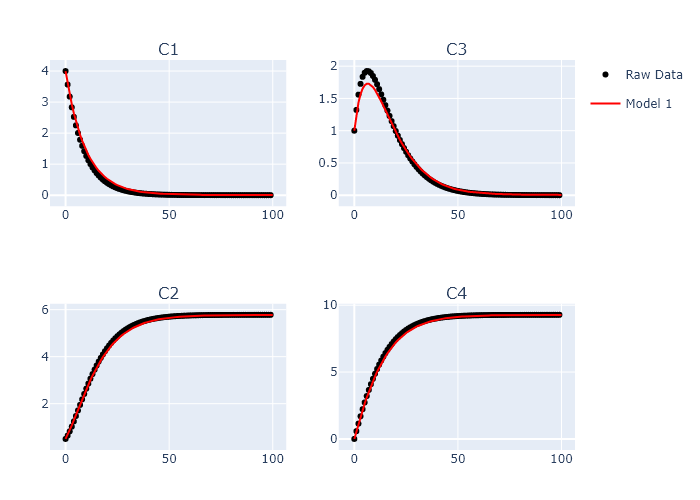

In [37]:
plot_it(xk_RAW_DATA, xk_OUTPUT, 4, subplot_titles=["C1" "C2"; "C3" "C4"])

### ODE NN:

In [38]:
#Indicate example #37:
Z = 37;   occurences=1000; dt= 0.001; account_for_time = true; pull_raw_data = true;

#Pull NN parameter data from CSV files: 
numLayers, xk_RAW_DATA, THETA, CCOEFF_BASE, CCOEFF_TIME = example_set_up(Z, account_for_time = account_for_time, pull_raw_data = pull_raw_data)
xk_init_cond = Float64.(xk_RAW_DATA[:, 1])

#Generate base-value of abs normal coefficients:
Z_coeff, L_coeff, J_coeff, Y_coeff, BETA_BASE, BETA_TIME = NNInput.generate_RELU(THETA, CCOEFF_BASE, CCOEFF_TIME)
#Iterate through and calculate ODE x^{k} values  
xk_OUTPUT = NNInput.solve_ODE(
    xk_init_cond, dt, occurences,
    Z_coeff, L_coeff, J_coeff, Y_coeff, BETA_BASE, BETA_TIME,
    solve_mode = NNInput.BY_LCP
)

terminationStatus = MathOptInterface.LOCALLY_SOLVED
terminationStatus = MathOptInterface.LOCALLY_SOLVED
terminationStatus = MathOptInterface.LOCALLY_SOLVED
terminationStatus = MathOptInterface.LOCALLY_SOLVED
terminationStatus = MathOptInterface.LOCALLY_SOLVED
terminationStatus = MathOptInterface.LOCALLY_SOLVED
terminationStatus = MathOptInterface.LOCALLY_SOLVED
terminationStatus = MathOptInterface.LOCALLY_SOLVED
terminationStatus = MathOptInterface.LOCALLY_SOLVED
terminationStatus = MathOptInterface.LOCALLY_SOLVED
terminationStatus = MathOptInterface.LOCALLY_SOLVED
terminationStatus = MathOptInterface.LOCALLY_SOLVED
terminationStatus = MathOptInterface.LOCALLY_SOLVED
terminationStatus = MathOptInterface.LOCALLY_SOLVED
terminationStatus = MathOptInterface.LOCALLY_SOLVED
terminationStatus = MathOptInterface.LOCALLY_SOLVED
terminationStatus = MathOptInterface.LOCALLY_SOLVED
terminationStatus = MathOptInterface.LOCALLY_SOLVED
terminationStatus = MathOptInterface.LOCALLY_SOLVED
terminationS

3×1001 Matrix{Float64}:
 10.0  10.01     10.02     10.0301   …   27.3715    27.3996    27.4278
  5.0   5.00347   5.0071    5.01089       5.11618    5.11948    5.12288
  1.0   1.10075   1.20172   1.30292     325.955    326.709    327.464

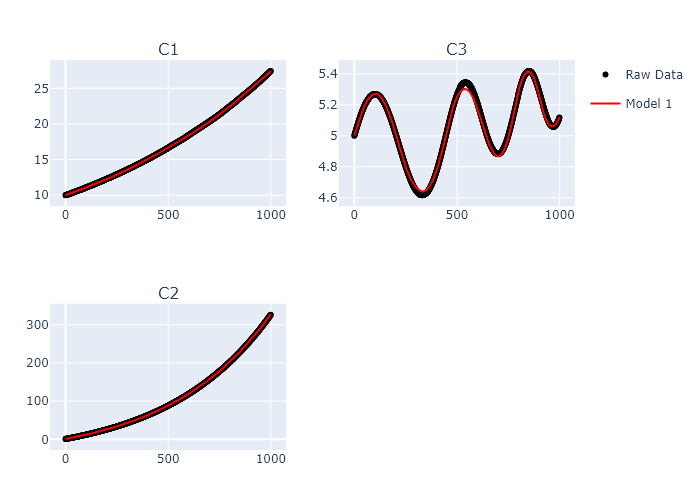

In [41]:
plot_it(xk_RAW_DATA, xk_OUTPUT, 3, subplot_titles=["C1" "C2"; "C3" ""])